In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_excel("Online Retail.xlsx")

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [12]:
df.shape

(541909, 8)

In [13]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [14]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(5268)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'].isnull().sum()

np.int64(0)

In [20]:
df['Quantity'].min()


np.int64(-80995)

In [21]:
df['UnitPrice'].min()

np.float64(0.0)

In [23]:
(df['Quantity'] <= 0).sum()

np.int64(8872)

In [24]:
(df['UnitPrice'] <= 0).sum()

np.int64(40)

In [25]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [26]:
df.shape

(392692, 8)

In [27]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [28]:
df['TotalAmount'].mean()

np.float64(22.631499735161402)

In [29]:
df.groupby('CustomerID')['InvoiceNo'].nunique().mean()

np.float64(4.272014753342554)

In [30]:
df.groupby('CustomerID')['TotalAmount'].sum().mean()

np.float64(2048.688080682342)

In [31]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [32]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [33]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [34]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [35]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [38]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

In [39]:
from sklearn.cluster import KMeans

In [40]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

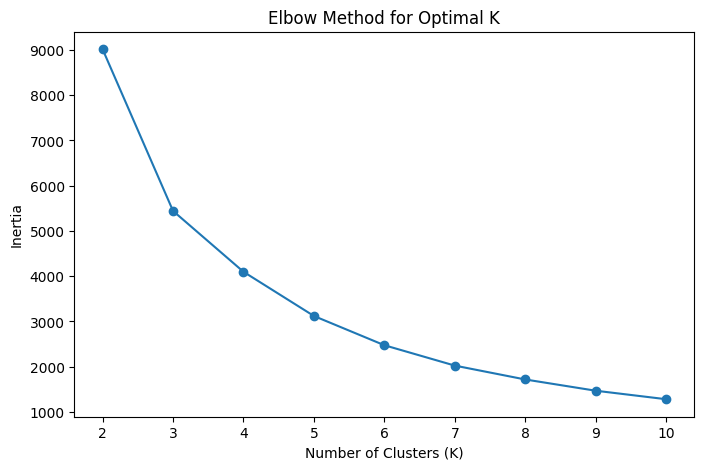

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [43]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [44]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


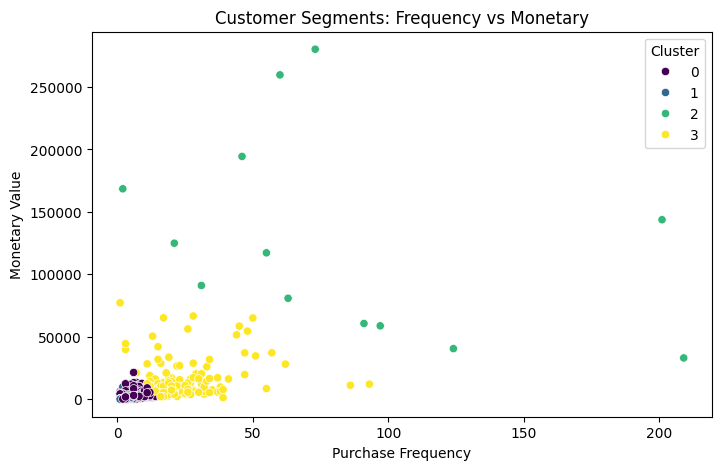

In [47]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)
plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.show()

In [48]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


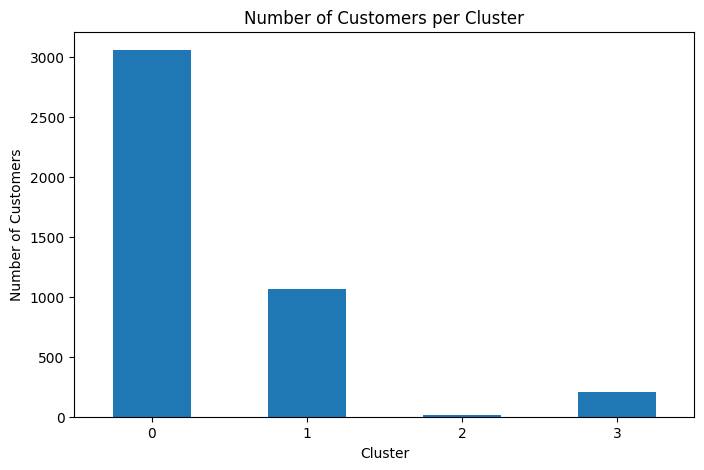

In [50]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)
plt.show()